In [1]:
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import librosa
from matplotlib.gridspec import GridSpec
from multiprocessing import Pool
import pandas as pd
from tqdm import tqdm
import os
from glob import glob
from functools import partial
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import librosa
from matplotlib.gridspec import GridSpec
import os

图表已生成并保存为: /data/250010171/code/EigeNet_discriminant/data/octave_analysis/edc_gcc_comparisons.png


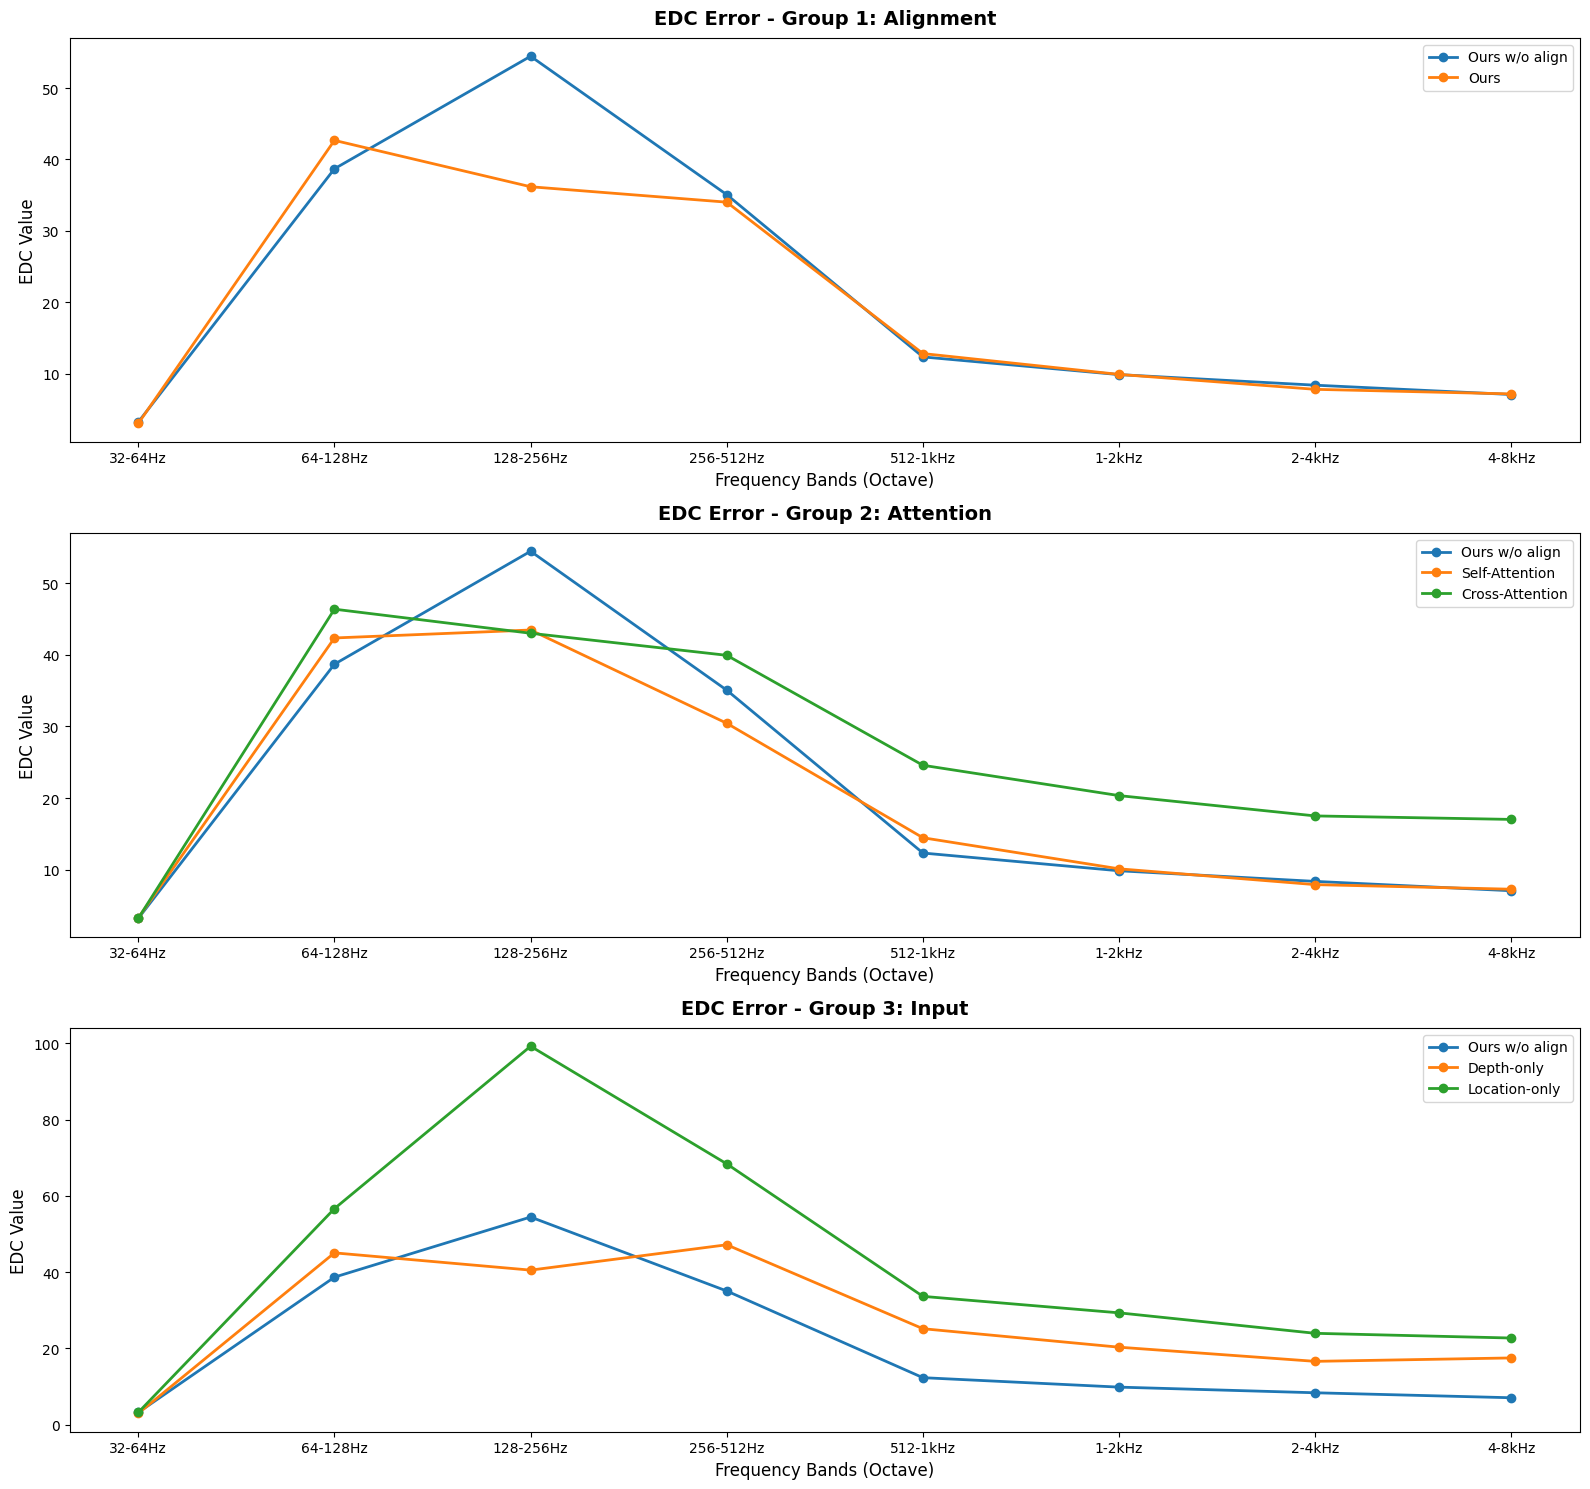

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 数据加载与清洗
# ==========================================
df_edc = pd.read_csv('/data/250010171/code/EigeNet_discriminant/data/octave_analysis/edc.csv')

# 清除列名中可能存在的多余空格（重要：防止 "oct1 " 导致找不到列）
df_edc.columns = df_edc.columns.str.strip()

# 清除模型名称（model列）中可能存在的多余空格
df_edc['model'] = df_edc['model'].str.strip()

# 将 model 列设置为索引
df_edc.set_index('model', inplace=True)

# ==========================================
# 2. 定义对比组
# ==========================================
groups = [
    {
        'title': 'Group 1: Alignment',
        'models': [
            'Ours w/o align', 
            'Ours'
        ]
    },
    {
        'title': 'Group 2: Attention',
        'models': [
            'Ours w/o align', 
            'Self-Attention', 
            'Cross-Attention'
        ]
    },
    {
        'title': 'Group 3: Input',
        'models': [
            'Ours w/o align', 
            'Depth-only', 
            'Location-only'
        ]
    }
]

# ==========================================
# 3. 准备 X 轴标签和要截取的数据列
# ==========================================
# EDC 保留所有频段
cols_edc = df_edc.columns.tolist()
x_labels_edc = [col.split(' ')[1].strip('()') for col in cols_edc]

# ==========================================
# 4. 绘制图表 (3行2列)
# ==========================================
# 左边一列画 EDC，右边一列画 GCC
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 15))

for i, group in enumerate(groups):
    ax_edc = axes[i]  # 左侧 EDC
    
    for model in group['models']:
        # 简化图例名称，去除前缀
        short_name = model.replace('discriminant_', '')
        
        # 提取数据
        y_edc = df_edc.loc[model, cols_edc].values
        
        # 绘制 EDC
        ax_edc.plot(x_labels_edc, y_edc, marker='o', linewidth=2, label=short_name)
        
    
    # --- EDC 子图格式化 ---
    ax_edc.set_title(f"EDC Error - {group['title']}", fontsize=14, fontweight='bold', pad=10)
    ax_edc.set_xlabel('Frequency Bands (Octave)', fontsize=12)
    ax_edc.set_ylabel('EDC Value', fontsize=12)
    ax_edc.legend(fontsize=10)
    ax_edc.grid(False)
    
    
# 自动调整子图间距，防止文字重叠
plt.tight_layout()

# 保存图表
output_filename = '/data/250010171/code/EigeNet_discriminant/data/octave_analysis/edc_gcc_comparisons.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"图表已生成并保存为: {output_filename}")